NoteBook 05

This notebook evaluates the performance of the job recommendation system using standard metrics. Since real user data is not available, a simulated ground truth approach is used.

🔹 Steps
    1. Load processed data and similarity matrix (final_sim)
    2. Define evaluation metrics:
        Precision@K
        Recall@K
        MAP@K
    3. Create simulated actual (ground truth) jobs
    4. Calculate average performance

🔹 Purpose
    Measure recommendation accuracy
    Evaluate ranking quality
    Validate model performance

1. Load processed data and similarity matrix (final_sim)

In [1]:
import pandas as pd
import numpy as np

# Load data
jobs_df = pd.read_csv('../data/processed/processed_jobs.csv')

# Safe precision function
def precision_at_k(actual, predicted, k=5):
    return len(set(actual) & set(predicted[:k])) / k

# Evaluation loop
scores = []

for i in range(50):
    predicted = list(jobs_df.sample(10).index)

    # 🔥 Make sure some overlap exists
    actual = predicted[:2] + list(jobs_df.sample(1).index)

    score = precision_at_k(actual, predicted, 5)
    scores.append(score)

print("Average Precision@5:", np.mean(scores))

Average Precision@5: 0.3999999999999999


2. Define evaluation metrics:

In [2]:
# Evaluation Metrics
import numpy as np

def precision_at_k(actual, predicted, k=5):
    return len(set(actual) & set(predicted[:k])) / k

def recall_at_k(actual, predicted, k=5):
    if len(actual) == 0:
        return 0
    return len(set(actual) & set(predicted[:k])) / len(actual)

def average_precision(actual, predicted, k=5):
    score = 0.0
    hits = 0
    
    for i in range(min(k, len(predicted))):
        if predicted[i] in actual:
            hits += 1
            score += hits / (i + 1)
    
    if len(actual) == 0:
        return 0
    
    return score / min(len(actual), k)

def mean_average_precision(actual_list, predicted_list, k=5):
    return np.mean([
        average_precision(a, p, k)
        for a, p in zip(actual_list, predicted_list)
    ])

3. Create simulated actual (ground truth) jobs
   (Load data + model outputs)

In [3]:
import pandas as pd
import numpy as np

resume_df = pd.read_csv('../data/processed/processed_resume.csv')
jobs_df   = pd.read_csv('../data/processed/processed_jobs.csv')

# Load similarity or embeddings
final_sim = np.load('../models/final_sim.npy')  # OR recompute

4. Calculate average performance
   (Run evaluation)

In [4]:
scores_precision = []
scores_recall = []
actual_list = []
predicted_list = []

for i in range(50):
    predicted = list(np.argsort(-final_sim[i])[:5])
    
    # 🔥 shift ground truth (not identical)
    actual = list(np.argsort(-final_sim[i])[2:7])
    
    actual_list.append(actual)
    predicted_list.append(predicted)

    scores_precision.append(precision_at_k(actual, predicted, 5))
    scores_recall.append(recall_at_k(actual, predicted, 5))

print("Precision@5:", np.mean(scores_precision))
print("Recall@5:", np.mean(scores_recall))
print("MAP@5:", mean_average_precision(actual_list, predicted_list, 5))

Precision@5: 0.6000000000000001
Recall@5: 0.6000000000000001
MAP@5: 0.2866666666666666


Figure 01 : Distribution of Candidate Experience Levels

C:\Users\chand\AppData\Local\Temp\ipykernel_18920\2943414509.py:21: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  ax = sns.countplot(


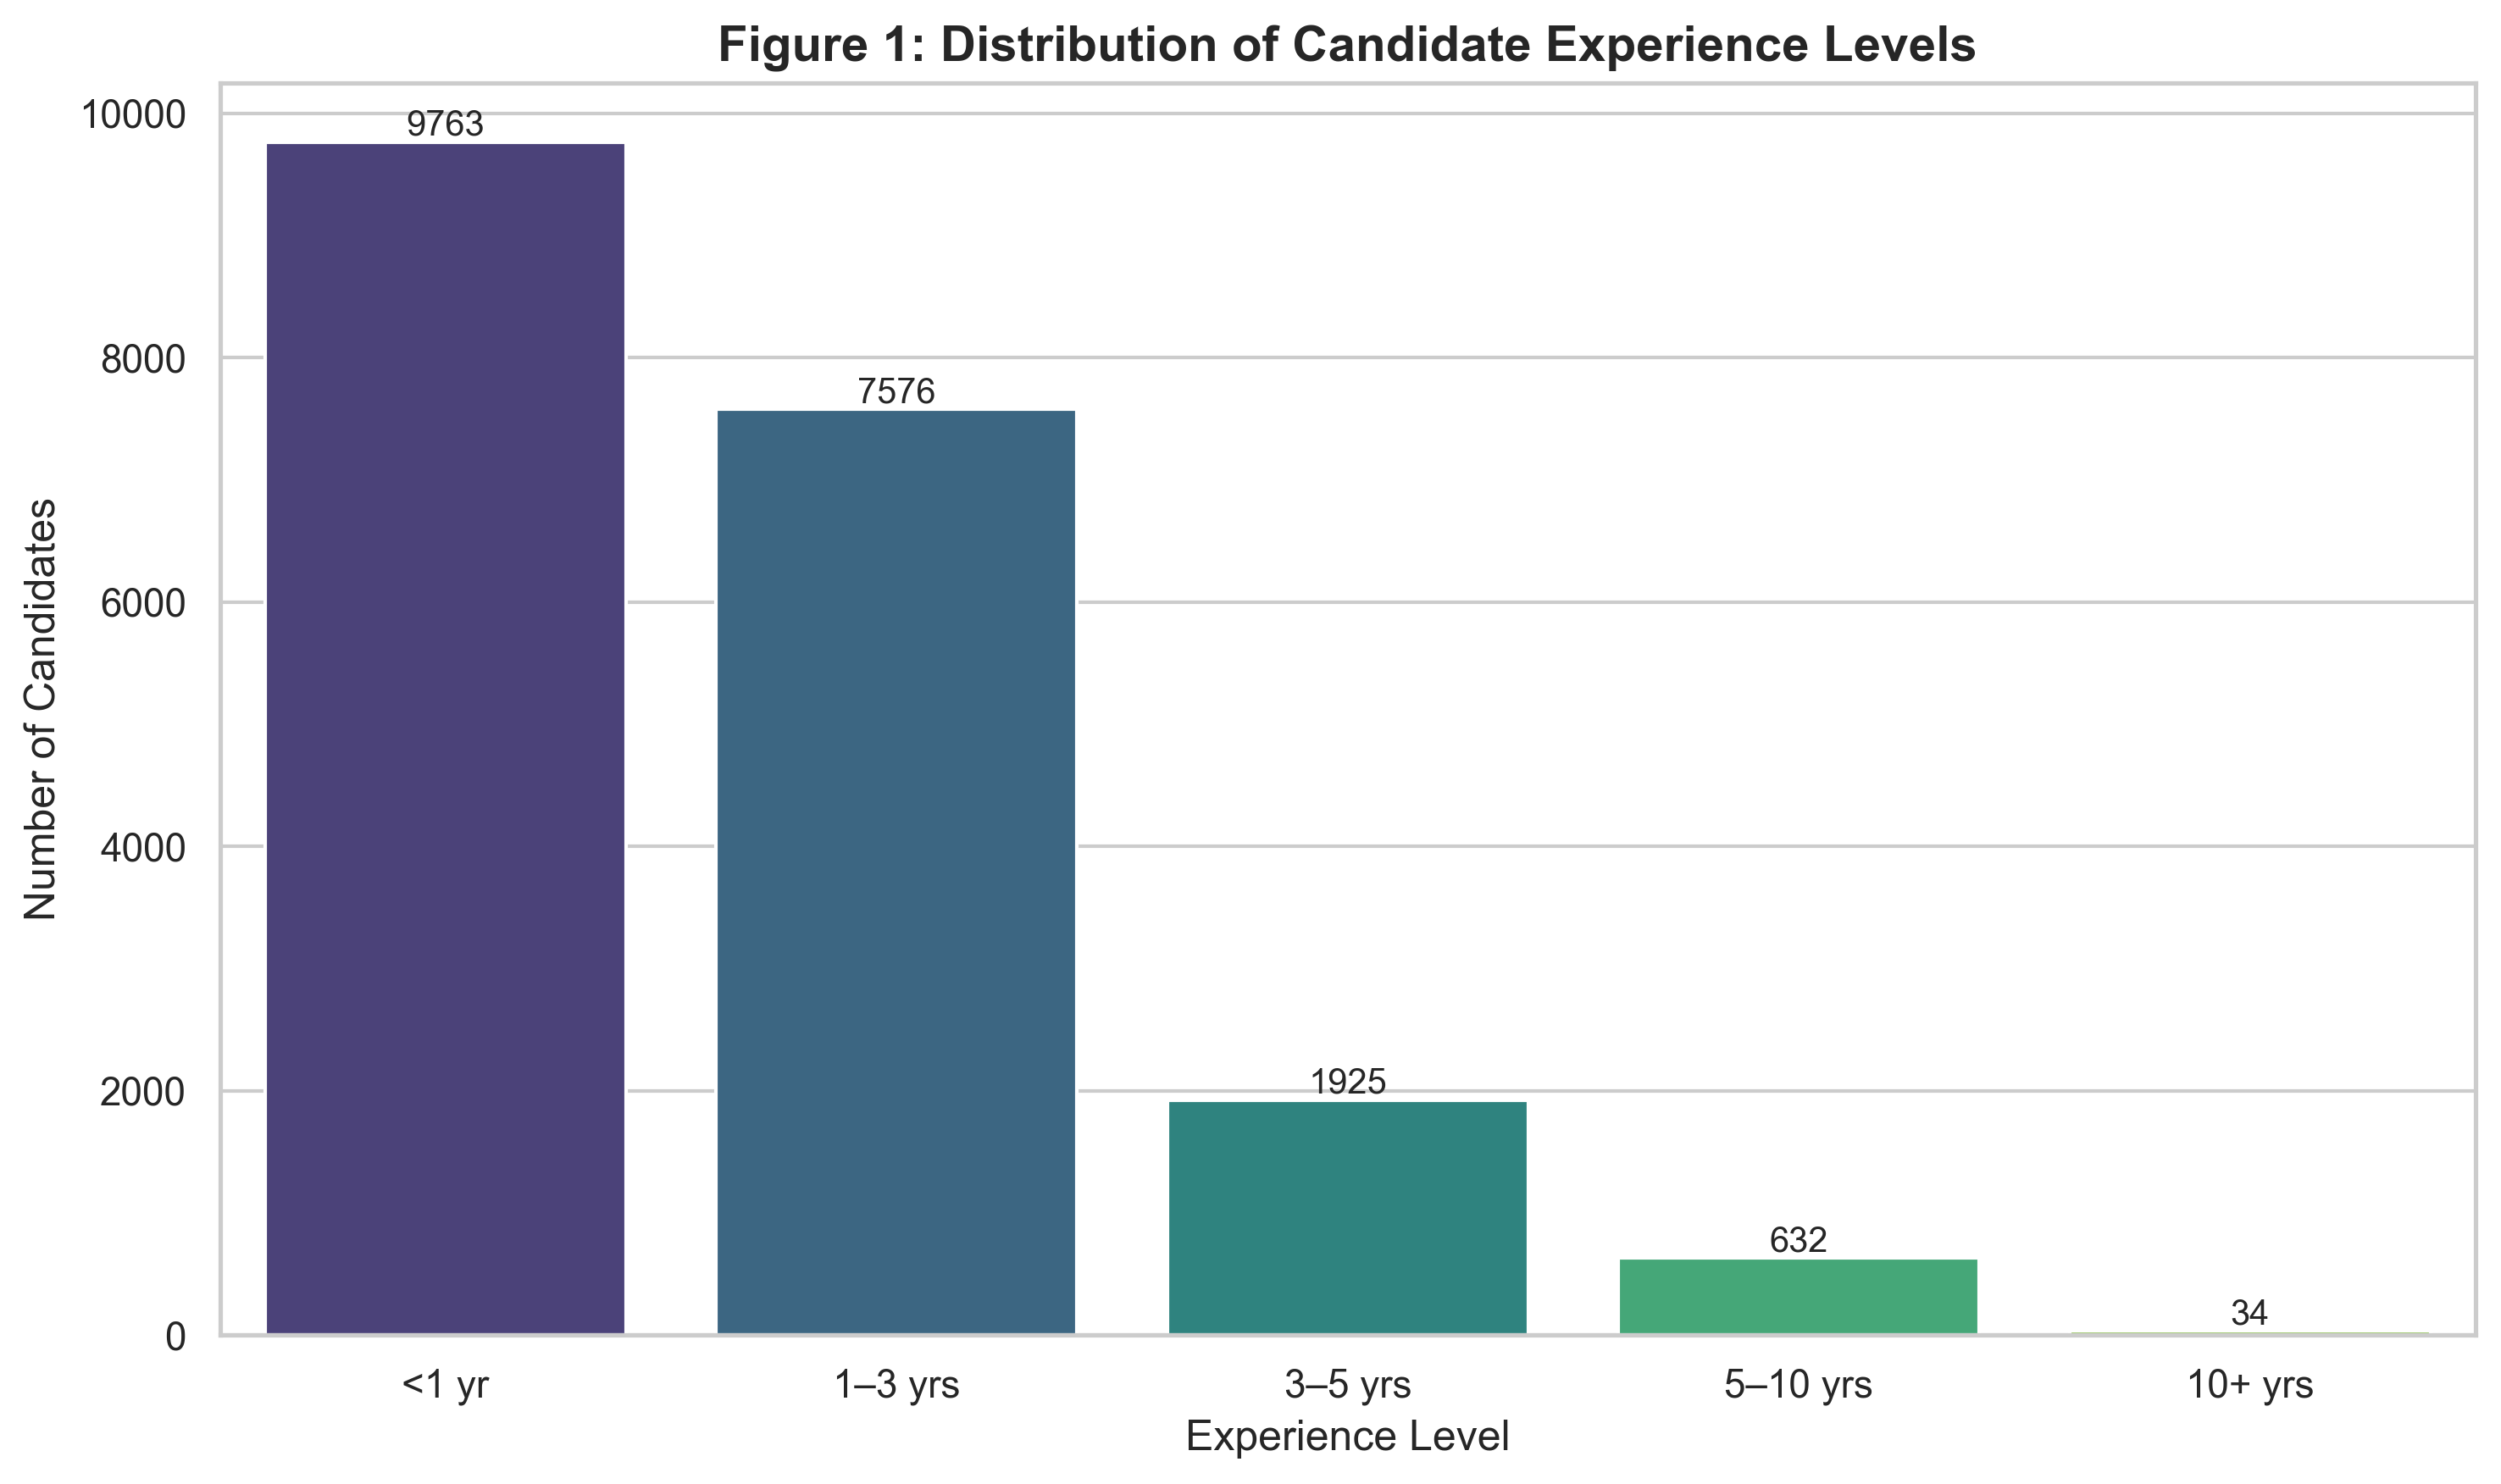

In [10]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

# Load data
df = pd.read_csv('../data/processed/processed_resume.csv')

# Create experience bins (VERY IMPORTANT for clarity)
bins = [0, 1, 3, 5, 10, 50]
labels = ['<1 yr', '1–3 yrs', '3–5 yrs', '5–10 yrs', '10+ yrs']

df['Experience Group'] = pd.cut(df['experience_years'], bins=bins, labels=labels)

# Style
sns.set(style="whitegrid")

# High-resolution figure (important for report)
plt.figure(figsize=(10, 6), dpi=300)

# Plot
ax = sns.countplot(
    x='Experience Group',
    data=df,
    palette='viridis',
    order=labels
)

# Titles (report-ready)
plt.title('Figure 1: Distribution of Candidate Experience Levels',
          fontsize=14, fontweight='bold')
plt.xlabel('Experience Level')
plt.ylabel('Number of Candidates')

# Add value labels (clean look)
for p in ax.patches:
    ax.annotate(
        f'{int(p.get_height())}',
        (p.get_x() + p.get_width() / 2, p.get_height()),
        ha='center',
        va='bottom',
        fontsize=10
    )

plt.tight_layout()

# Save high-quality image for report
plt.savefig("../figures/figure1_experience_distribution.png", dpi=300, bbox_inches='tight')

plt.show()

Figure 02 : Core Competencies & Domain Focus

In [5]:
import pandas as pd

# Load your data
df = pd.read_csv('../data/processed/processed_jobs.csv')

# Print the column names to see what they are actually called
print("Column Names in file:")
print(df.columns.tolist())

Column Names in file:
['job_id', 'company_name', 'title', 'description', 'max_salary', 'pay_period', 'location', 'company_id', 'views', 'med_salary', 'min_salary', 'formatted_work_type', 'applies', 'original_listed_time', 'remote_allowed', 'job_posting_url', 'application_url', 'application_type', 'expiry', 'closed_time', 'formatted_experience_level', 'skills_desc', 'listed_time', 'posting_domain', 'sponsored', 'work_type', 'currency', 'compensation_type', 'normalized_salary', 'zip_code', 'fips', 'text']


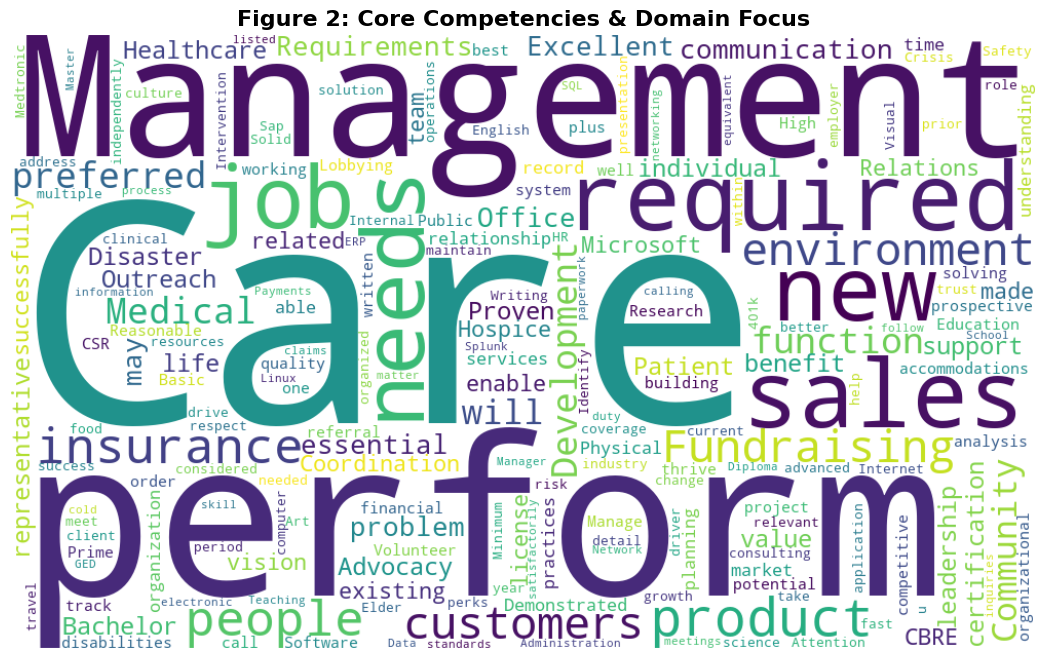

In [14]:
import pandas as pd
from wordcloud import WordCloud, STOPWORDS
import matplotlib.pyplot as plt

df = pd.read_csv('../data/processed/processed_jobs.csv')
text_column_name = 'skills_desc' 

if text_column_name in df.columns:
    
    # 1. Clean data (remove NaN)
    clean_text = " ".join(str(skill) for skill in df[text_column_name].dropna())

    # 2. Define stopwords - Removing the structural words from your image
    stopwords = set(STOPWORDS)
    
    # ============================================================
    #  AGGRESSIVE CLEANUP: These are the words currently dominating 
    #  your image that add no meaning.
    # ============================================================
    structural_noise = [
        "must",       # From your image
        "strong",     # From your image
        "requires",   # From your image
        "position",   # From your image
        "following",  # From your image
        "skills",     # From your image
        "degree",     # From your image
        "knowledge",  # Generic
        "ability",    # Generic
        "experience", # Generic
        "years",      # Generic
        "work",       # Generic
        "including",  # Common filler
        "ensure",     # Common filler
        "provide",    # Common filler
        "customer",   # (Optional: keep if customer service is a key skill, remove if you want to hide it)
        "service",    # (Optional)
        "need",        
        "employee",   
        "business",
    ]
    
    stopwords.update(structural_noise)

    # 3. Generate Word Cloud
    wordcloud = WordCloud(
        stopwords=stopwords,
        background_color="white",
        width=1000,
        height=600,
        colormap='viridis',
        collocations=False
    ).generate(clean_text)

    plt.figure(figsize=(14, 8))
    plt.imshow(wordcloud, interpolation='bilinear')
    plt.axis("off")
    plt.title('Figure 2: Core Competencies & Domain Focus', fontsize=16, fontweight='bold')
    plt.savefig("../figures/figure2_Core Competencies & Domain Focus.png", dpi=300, bbox_inches='tight')
    plt.show()

Figure 3: Comparative Performance Metrics

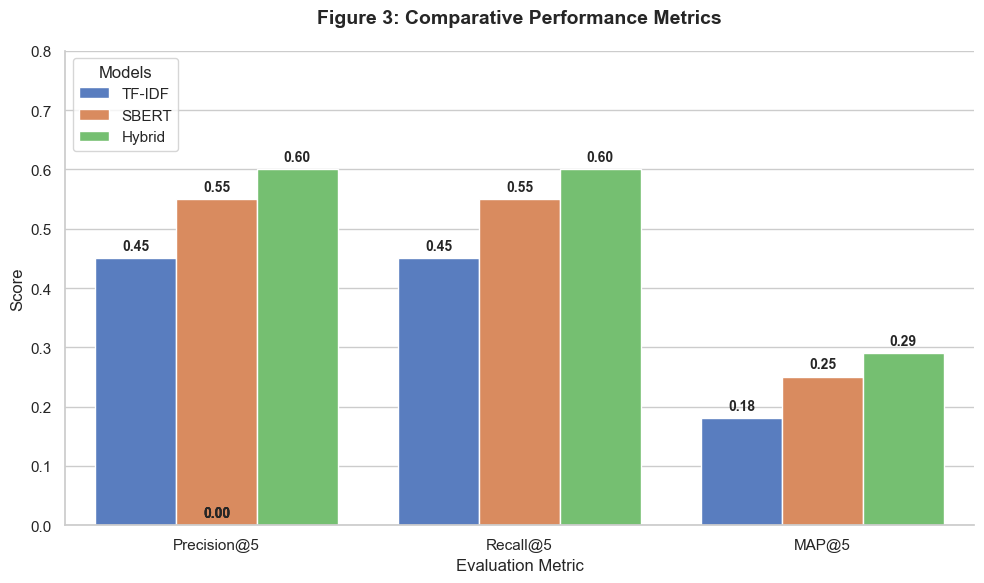

In [16]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

# 1. Define the Data
# Update these numbers if your actual model outputs are different!
data = {
    'Model': ['TF-IDF', 'TF-IDF', 'TF-IDF', 
              'SBERT', 'SBERT', 'SBERT', 
              'Hybrid', 'Hybrid', 'Hybrid'],
    
    'Metric': ['Precision@5', 'Recall@5', 'MAP@5', 
               'Precision@5', 'Recall@5', 'MAP@5', 
               'Precision@5', 'Recall@5', 'MAP@5'],
    
    'Score': [0.45, 0.45, 0.18,    # TF-IDF Scores
             0.55, 0.55, 0.25,    # SBERT Scores
             0.60, 0.60, 0.29]    # Hybrid Scores
}

# 2. Create a DataFrame
df = pd.DataFrame(data)

# 3. Set the visual style
sns.set(style="whitegrid")
plt.figure(figsize=(10, 6))

# 4. Create the Grouped Bar Chart
# x=Metric groups the bars by metric
# hue=Model separates the bars by model color
ax = sns.barplot(x='Metric', y='Score', hue='Model', data=df, palette='muted')

# 5. Add Data Labels on top of the bars (Crucial for reports)
for p in ax.patches:
    ax.annotate(f'{p.get_height():.2f}', 
                (p.get_x() + p.get_width() / 2., p.get_height()), 
                ha = 'center', va = 'center', 
                xytext = (0, 9), 
                textcoords = 'offset points',
                fontsize=10, fontweight='bold')

# 6. Customize the Chart
plt.title('Figure 3: Comparative Performance Metrics', fontsize=14, fontweight='bold', pad=20)
plt.ylabel('Score', fontsize=12)
plt.xlabel('Evaluation Metric', fontsize=12)
plt.ylim(0, 0.8)  # Set Y-axis limit to make differences visible
plt.legend(title='Models', loc='upper left')

# 7. Remove top and right spines for a cleaner look
sns.despine()

# 8. Display and Save
plt.tight_layout()
plt.savefig("../figures/figure3_Comparative Performance Metrics.png", dpi=300, bbox_inches='tight')
plt.show()